# Applying Corrected Cluster Labels

This notebook loads the original extraction paths (`valid_paths.npy`) to correctly align with `dino_clusters.npy`, maps the cluster IDs to string labels, and generates a visual summary grid.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

outputs_dir = "../outputs"
os.makedirs(outputs_dir, exist_ok=True)

# Define the mapping from the user
cluster_mapping = {
    -1: "Noise / Mixed",
    0: "Scientific Plots & Charts",
    1: "Diffraction Patterns",
    2: "Elemental Mapping",
    3: "Macroscopic Samples",
    4: "Experimental Equipment",
    5: "Fracture Cross-Sections",
    6: "Atomic-Scale Microscopy",
    7: "SEM Morphology",
    8: "EBSD Maps",
    9: "Element Distribution Maps",
    10: "Grain Boundary Structures",
    11: "Metallographic Microstructures"
}


In [2]:
print("Loading un-sorted alignment data...")
# MUST load valid_paths.npy to match dino_clusters.npy order
valid_paths = np.load("../embeddings/valid_paths.npy", allow_pickle=True)
clusters = np.load("dino_clusters.npy")

# Transform colab paths to local relative paths
image_paths = []
for p in valid_paths:
    basename = os.path.basename(p.replace('\\', '/'))
    image_paths.append(os.path.join("..\\raw_images", basename))

print(f"Total images loaded: {len(image_paths)}")
print(f"Total clusters loaded: {len(clusters)}")

assert len(image_paths) == len(clusters), "Mismatch in array lengths!"


Loading un-sorted alignment data...
Total images loaded: 51301
Total clusters loaded: 51301


In [3]:
df = pd.DataFrame({
    "image_path": image_paths,
    "cluster_id": clusters
})

df["label"] = df["cluster_id"].map(cluster_mapping)

print("Mapping complete. Dataset preview:")
display(df.head())
display(df.tail())


Mapping complete. Dataset preview:


,image_path,cluster_id,label
0,..\raw_images\img12065_C.jpg,4,Experimental Equipment
1,..\raw_images\img5871_B.jpg,11,Metallographic Microstructures
2,..\raw_images\img770_D.jpg,11,Metallographic Microstructures
3,..\raw_images\img13287_D.jpg,1,Diffraction Patterns
4,..\raw_images\img299_D.jpg,0,Scientific Plots & Charts


,image_path,cluster_id,label
51296,..\raw_images\img13773_B.jpg,0,Scientific Plots & Charts
51297,..\raw_images\img13295_B.jpg,0,Scientific Plots & Charts
51298,..\raw_images\img5839_F_2.jpg,11,Metallographic Microstructures
51299,..\raw_images\img14522_B.jpg,3,Macroscopic Samples
51300,..\raw_images\img7942_B.jpg,11,Metallographic Microstructures


In [4]:
label_counts = df["label"].value_counts()
print("Label Distribution:")
display(label_counts.to_frame())


Label Distribution:


,count
label,
Scientific Plots & Charts,26397
Metallographic Microstructures,8323
Noise / Mixed,6986
SEM Morphology,1995
EBSD Maps,1988
Element Distribution Maps,1654
Elemental Mapping,750
Macroscopic Samples,725
Diffraction Patterns,656


In [5]:
output_csv_path = os.path.join(outputs_dir, "labelled_dataset.csv")
df.to_csv(output_csv_path, index=False)
print(f"Successfully saved correctly aligned labelled dataset to {output_csv_path}")


Successfully saved correctly aligned labelled dataset to ../outputs\labelled_dataset.csv


Generating visual grid...


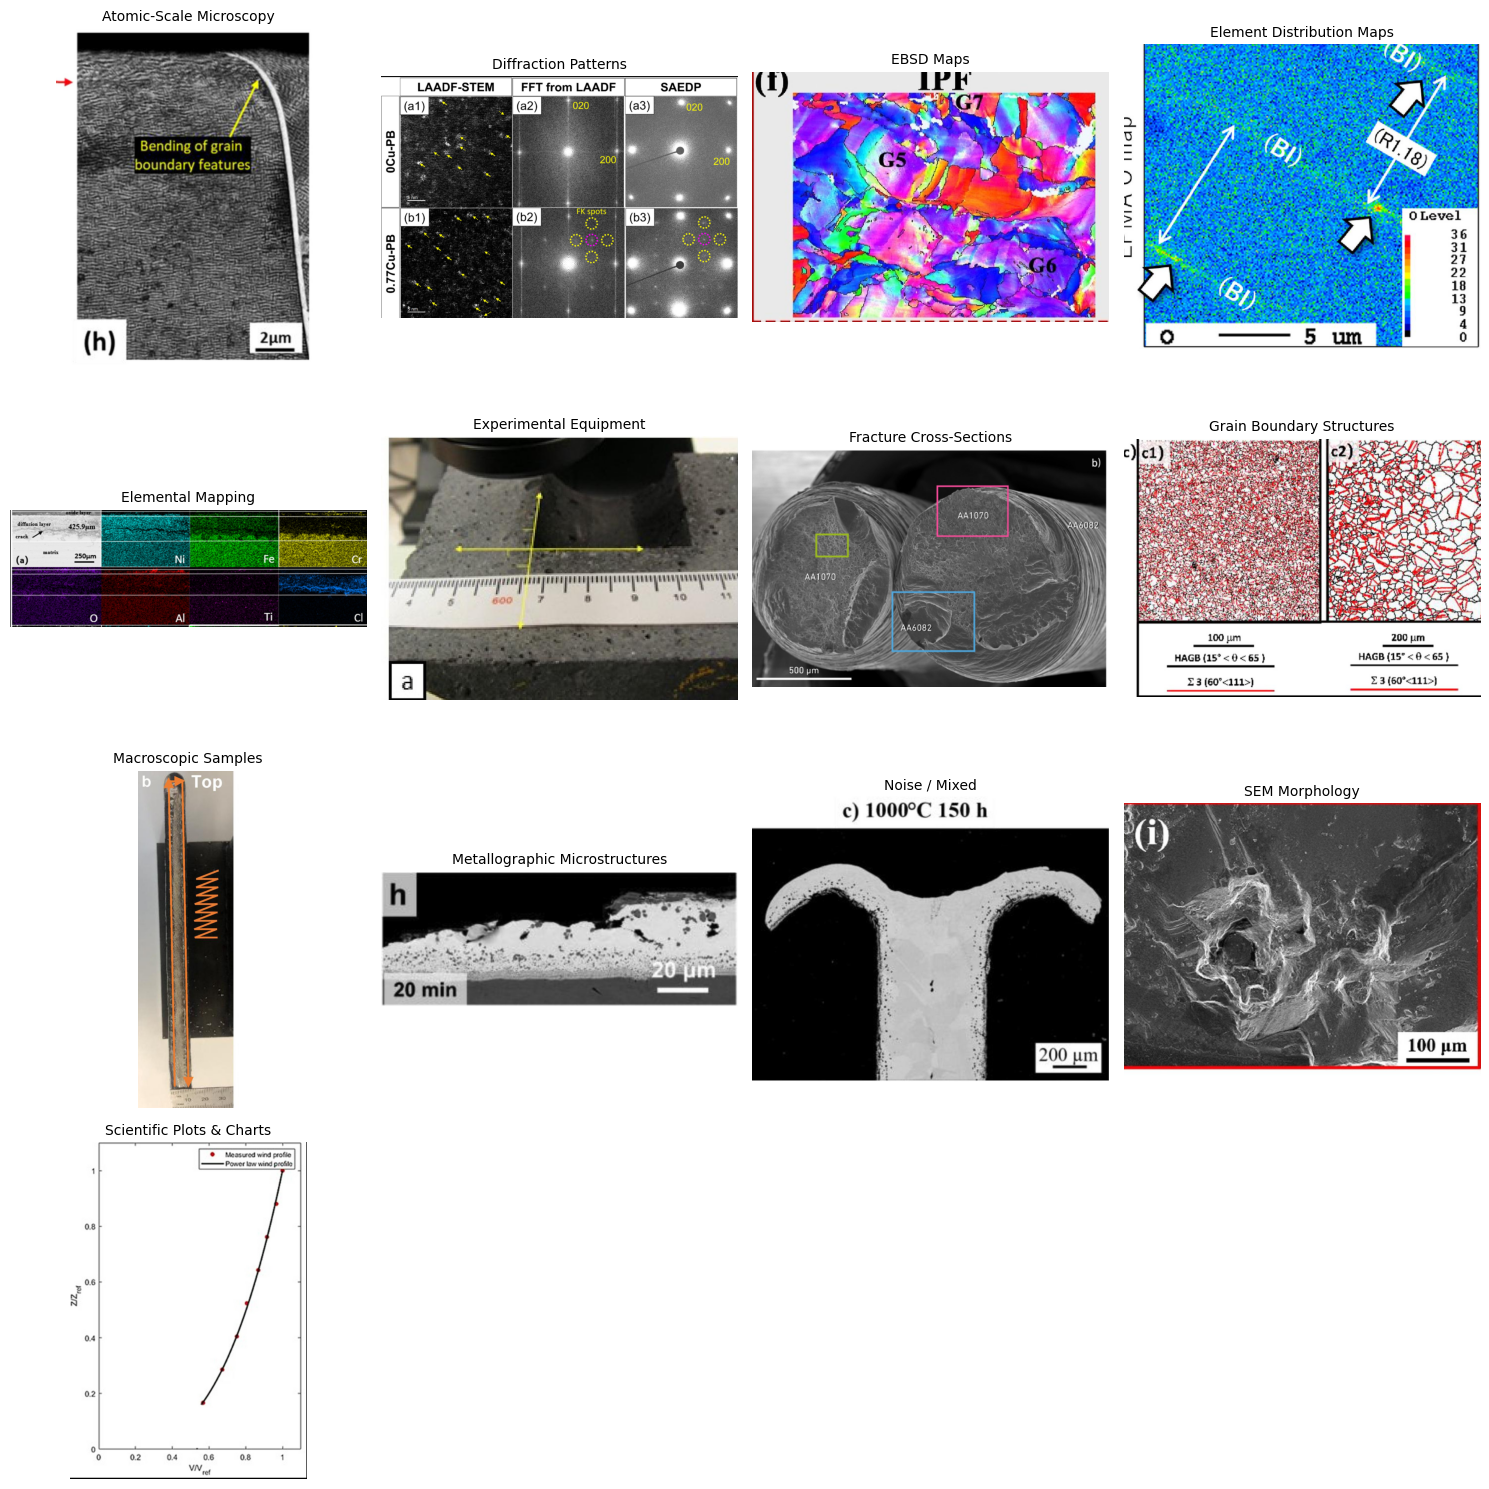

In [6]:
# Visualization grid
print("Generating visual grid...")
sample_df = df.groupby('label').sample(n=1, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()

for idx, row in sample_df.iterrows():
    img_path = row['image_path']
    if not os.path.exists(img_path):
        img_path = os.path.join("..", img_path)
        
    try:
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(row['label'], fontsize=10, wrap=True)
    except Exception as e:
        axes[idx].set_title(f"Error loading:\n{row['label']}", fontsize=8)
    axes[idx].axis("off")

for i in range(len(sample_df), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()
